# Pseudotime analysis with PAGA and diffusion pseduotime

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
from scipy import sparse
from scipy.spatial.distance import cdist
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

load per cluster cluster assignmeents, edge weights, and feature matrix from Leiden clustering results for early response  at `/project/spott/cshan/fiber-seq/macrophage_project/clustering_TSS_methods/Leiden_Manhattan/TSS_1000`

In [2]:
selected_genes = ["CXCL2", "IL1A", "IL1B", "IL6", "IL8", "TNF", "PTGS2", "RELB"]
cluster_dir = Path("/project/spott/cshan/fiber-seq/macrophage_project/clustering_TSS_methods/Leiden_Manhattan/TSS_1000")
file_types = {
    "assignments": "read_cluster_assignments_{gene}.tsv",
    "edges": "knn_edges_{gene}.tsv",
    "features": "feature_matrix_{gene}.tsv",
    "profiles": "cluster_profiles_{gene}.tsv",
    "timepoint_counts": "cluster_timepoint_counts_{gene}.tsv",
    "parameters": "run_parameters_{gene}.tsv",
    "window_annotation": "window_annotation_{gene}.tsv",
}

# loop over the genes and open pre-read clsuster assignments, edge weights, and feature matrix 

def load_cluster_results(gene, cluster_dir=cluster_dir):

    gene_dir = cluster_dir / gene / "bin0"

    # Find k*/tables, e.g. CXCL2/bin0/k5/tables
    table_dirs = list(gene_dir.glob("k*/tables"))

    if len(table_dirs) == 0:
        raise FileNotFoundError(
            f"No k*/tables directory found for {gene} under {gene_dir}"
        )

    if len(table_dirs) > 1:
        raise ValueError(
            f"Multiple k*/tables directories found for {gene}: {table_dirs}"
        )

    table_dir = table_dirs[0]

    assignments_file = table_dir / file_types["assignments"].format(gene=gene)
    edges_file = table_dir / file_types["edges"].format(gene=gene)
    features_file = table_dir / file_types["features"].format(gene=gene)
    profiles_file = table_dir / file_types["profiles"].format(gene=gene)
    timepoint_counts_file = table_dir / file_types["timepoint_counts"].format(gene=gene)
    parameters_file = table_dir / file_types["parameters"].format(gene=gene)
    window_annotation_file = table_dir / file_types["window_annotation"].format(gene=gene)

    # Read TSV files
    assignments = pd.read_csv(assignments_file, sep="\t")
    edges = pd.read_csv(edges_file, sep="\t")
    features = pd.read_csv(features_file, sep="\t")
    profiles = pd.read_csv(profiles_file, sep="\t")
    timepoint_counts = pd.read_csv(timepoint_counts_file, sep="\t")
    parameters = pd.read_csv(parameters_file, sep="\t")
    window_annotation = pd.read_csv(window_annotation_file, sep="\t")

    return {
        "assignments": assignments,
        "edges": edges,
        "features": features,
        "profiles": profiles,
        "timepoint_counts": timepoint_counts,
        "parameters": parameters,
        "window_annotation": window_annotation,
        "table_dir": table_dir,
    }

In [3]:
cluster_results = {}

for gene in selected_genes:
    print(f"Loading {gene}...")
    cluster_results[gene] = load_cluster_results(gene)

Loading CXCL2...
Loading IL1A...
Loading IL1B...
Loading IL6...
Loading IL8...
Loading TNF...
Loading PTGS2...
Loading RELB...


cluster assignments

In [4]:
cluster_results["CXCL2"]["assignments"].head()

,RID,cluster,sample_name,chr,start,end,strand,timepoint
0,m84241_260505_182714_s3/120329826/ccs,cluster1,LPS_5,chr4,74095558,74102241,-,5
1,m84241_260505_182714_s3/141432141/ccs,cluster2,LPS_10,chr4,74095339,74106615,-,10
2,m84241_260505_182714_s3/149425764/ccs,cluster1,LPS_5,chr4,74090158,74100661,+,5
3,m84241_260505_182714_s3/154011751/ccs,cluster4,LPS_5,chr4,74093263,74104774,-,5
4,m84241_260505_182714_s3/165874152/ccs,cluster3,LPS_10,chr4,74087666,74111548,-,10


cluster edge weights

In [5]:
cluster_results["CXCL2"]["edges"].head()

,from,to,weight,manhattan_distance
0,m84241_260505_182714_s3/120329826/ccs,m84241_260505_203017_s4/68358095/ccs,0.514164,66
1,m84241_260505_182714_s3/120329826/ccs,m84241_260614_075102_s1/25236166/ccs,0.514164,66
2,m84241_260505_182714_s3/120329826/ccs,m84241_260505_182714_s3/65079572/ccs,0.509008,67
3,m84241_260505_182714_s3/120329826/ccs,m84241_260614_115715_s3/161744708/ccs,0.509008,67
4,m84241_260505_182714_s3/120329826/ccs,m84241_260505_182714_s3/37948967/ccs,0.503903,68


cluster features

In [7]:
cluster_results["CXCL2"]["features"].head(10)

,RID,sample_name,timepoint,cluster,74098195,74098196,74098198,74098199,74098200,74098202,...,74100181,74100182,74100184,74100185,74100186,74100188,74100189,74100191,74100192,74100193
0,m84241_260505_182714_s3/120329826/ccs,LPS_5,5,cluster1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,m84241_260505_182714_s3/141432141/ccs,LPS_10,10,cluster2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,m84241_260505_182714_s3/149425764/ccs,LPS_5,5,cluster1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,m84241_260505_182714_s3/154011751/ccs,LPS_5,5,cluster4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,m84241_260505_182714_s3/165874152/ccs,LPS_10,10,cluster3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,m84241_260505_182714_s3/181602117/ccs,LPS_10,10,cluster4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,m84241_260505_182714_s3/192546611/ccs,LPS_10,10,cluster1,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
7,m84241_260505_182714_s3/21103640/ccs,LPS_5,5,cluster2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,m84241_260505_182714_s3/228066721/ccs,LPS_5,5,cluster4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,m84241_260505_182714_s3/242484068/ccs,LPS_0,0,cluster4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


cluster profiles
    - summarizes the average m6A pattern of each Leiden cluster. After clustering reads pooled across the four LPS timepoints, we average their binary m6A calls (1 = marked, 0 = unmarked) at each feature.
  With bin = 0, each feature column represents an individual genomic position, and each row represents a cluster. A value of 0.7 means 70% of reads in that cluster carry an m6A call at that position. For CXCL2, the table contains five
  clusters across 827 positions, describing how m6A marking varies across the region between clusters

In [9]:
cluster_results["CXCL2"]["profiles"].head()

,cluster,74098195,74098196,74098198,74098199,74098200,74098202,74098204,74098206,74098207,...,74100181,74100182,74100184,74100185,74100186,74100188,74100189,74100191,74100192,74100193
0,cluster1,0.049180,0.016393,0.016393,0.065574,0.016393,0.081967,0.000000,0.000000,0.032787,...,0.016393,0.016393,0.098361,0.065574,0.032787,0.081967,0.016393,0.016393,0.098361,0.016393
1,cluster2,0.000000,0.000000,0.000000,0.041667,0.020833,0.020833,0.000000,0.000000,0.020833,...,0.000000,0.020833,0.229167,0.062500,0.083333,0.083333,0.062500,0.041667,0.125000,0.041667
2,cluster3,0.022222,0.000000,0.022222,0.000000,0.000000,0.022222,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.066667,0.066667,0.000000,0.022222,0.000000,0.000000,0.044444,0.000000
3,cluster4,0.023810,0.000000,0.000000,0.047619,0.023810,0.071429,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.095238,0.047619,0.047619,0.023810,0.023810,0.000000,0.071429,0.000000
4,cluster5,0.052632,0.052632,0.000000,0.157895,0.105263,0.105263,0.052632,0.052632,0.000000,...,0.000000,0.000000,0.157895,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000,0.000000


time point counts

In [10]:
cluster_results["CXCL2"]["timepoint_counts"].head()

,cluster,sample_name,timepoint,n
0,cluster1,LPS_0,0,13
1,cluster1,LPS_5,5,18
2,cluster1,LPS_10,10,13
3,cluster1,LPS_15,15,17
4,cluster2,LPS_0,0,8


window annotations

In [12]:
cluster_results["CXCL2"]["window_annotation"].head()

,feature,win_start,win_end,mid,n_sites
0,1,74098195,74098195,74098195,1
1,2,74098196,74098196,74098196,1
2,3,74098198,74098198,74098198,1
3,4,74098199,74098199,74098199,1
4,5,74098200,74098200,74098200,1


## construct annotation dataframe for PAGA

https://anndata.scverse.org/en/stable/generated/anndata.AnnData.html#anndata.AnnData

Annotated data matrix = observations x variables, observations contain metadata of the observations, and variables contain metadata of the varibales

`adata.x` - primary data matrix, shape = n_obs × n_vars = read x m6A sites, binary matrix of m6A calls (1 = marked, 0 = unmarked)

`adata.obs` - observations metadata, read ID, cluster assignment, time point, strrand, sample, coordinates

`adata.var` - gene metadata - m6a sites information: position, chr

`adata. obsp` - cell-cell connectivity grap = Manhatthan kNN graph

`adata.uns` - unstructured annotation, contains cluster edge weights and cluster profiles

1. select CXCL2

In [8]:
gene = "CXCL2"

assignments = cluster_results[gene]["assignments"].copy()
features = cluster_results[gene]["features"].copy()

print("Assignment RIDs unique:", assignments["RID"].is_unique)
print("Feature RIDs unique:", features["RID"].is_unique)

Assignment RIDs unique: True
Feature RIDs unique: True


2. set read ID as index, which is `obs_names` in the AnnData object

In [9]:
assignments = assignments.set_index("RID")
features = features.set_index("RID")

assignments.head()

,cluster,sample_name,chr,start,end,strand,timepoint
RID,,,,,,,
m84241_260505_182714_s3/120329826/ccs,cluster1,LPS_5,chr4,74095558,74102241,-,5
m84241_260505_182714_s3/141432141/ccs,cluster2,LPS_10,chr4,74095339,74106615,-,10
m84241_260505_182714_s3/149425764/ccs,cluster1,LPS_5,chr4,74090158,74100661,+,5
m84241_260505_182714_s3/154011751/ccs,cluster4,LPS_5,chr4,74093263,74104774,-,5
m84241_260505_182714_s3/165874152/ccs,cluster3,LPS_10,chr4,74087666,74111548,-,10


In [11]:
print(set(assignments.index) == set(features.index))
print("assignments:", assignments.shape)
print("features:", features.shape)

True
assignments: (215, 7)
features: (215, 830)


3. extract binary m6A matrix, this will become variable matrix in the AnnData object

In [ ]:
metadata_cols = [
    "sample_name",
    "timepoint",
    "cluster"
]

m6a_cols = [
    col
    for col in features.columns
    if col not in metadata_cols ]



X = features[m6a_cols].to_numpy(
    dtype=np.float32)

In [14]:
print("Total feature-table columns:", features.shape[1])
print("Number of m6A features:", len(m6a_cols))
print("First 10 m6A sites:")
print(m6a_cols[:10])

Total feature-table columns: 830
Number of m6A features: 827
First 10 m6A sites:
['74098195', '74098196', '74098198', '74098199', '74098200', '74098202', '74098204', '74098206', '74098207', '74098209']


4. Build observations metadata dataframe, this will become `obs` in the AnnData object

In [15]:
obs = assignments.copy()
obs["cluster"] = pd.Categorical(obs["cluster"])
obs["timepoint"] = obs["timepoint"].astype(int)

5. Build `var` dataframe, this will become `var` in the AnnData object

In [18]:
m6a_sites = [str(x) for x in m6a_cols]

var = pd.DataFrame(
    index=pd.Index(
        m6a_sites,
        name="m6a_site"
    )
)

var["position"] = [
    int(x)
    for x in m6a_sites
]

chromosomes = obs["chr"].unique()
var["chr"] = chr = chromosomes[0]

var.head()

,position,chr
m6a_site,,
74098195,74098195,chr4
74098196,74098196,chr4
74098198,74098198,chr4
74098199,74098199,chr4
74098200,74098200,chr4


In [19]:
print("X:", X.shape)
print("obs:", obs.shape)
print("var:", var.shape)

X: (215, 827)
obs: (215, 7)
var: (827, 2)


6. Create AnnData object

In [21]:
adata = ad.AnnData(
    X=X,
    obs=obs,
    var=var
)

adata

AnnData object with n_obs × n_vars = 215 × 827
    obs: 'cluster', 'sample_name', 'chr', 'start', 'end', 'strand', 'timepoint'
    var: 'position', 'chr'

`adata.X` = read x m6A binary matrix

In [22]:
adata.X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(215, 827), dtype=float32)

`adata.obs` = read metadata dataframe

In [23]:
adata.obs

,cluster,sample_name,chr,start,end,strand,timepoint
RID,,,,,,,
m84241_260505_182714_s3/120329826/ccs,cluster1,LPS_5,chr4,74095558,74102241,-,5
m84241_260505_182714_s3/141432141/ccs,cluster2,LPS_10,chr4,74095339,74106615,-,10
m84241_260505_182714_s3/149425764/ccs,cluster1,LPS_5,chr4,74090158,74100661,+,5
m84241_260505_182714_s3/154011751/ccs,cluster4,LPS_5,chr4,74093263,74104774,-,5
m84241_260505_182714_s3/165874152/ccs,cluster3,LPS_10,chr4,74087666,74111548,-,10
...,...,...,...,...,...,...,...
m84241_260614_140027_s4/263586661/ccs,cluster2,LPS_10,chr4,74083032,74101273,+,10
m84241_260614_140027_s4/36244249/ccs,cluster1,LPS_5,chr4,74096998,74110899,+,5
m84241_260614_140027_s4/44503142/ccs,cluster3,LPS_10,chr4,74090242,74111489,-,10


`adata.var` = read gene information dataframe

In [24]:
adata.var

,position,chr
m6a_site,,
74098195,74098195,chr4
74098196,74098196,chr4
74098198,74098198,chr4
74098199,74098199,chr4
74098200,74098200,chr4
...,...,...
74100188,74100188,chr4
74100189,74100189,chr4
74100191,74100191,chr4


In [26]:
print(adata)

print("\nObservations:")
print(adata.obs.head())

print("\nVariables:")
print(adata.var.head())

print("\nClusters:")
print(adata.obs["cluster"].value_counts())

print("\nTimepoints:")
print(
    adata.obs["timepoint"]
    .value_counts()
    .sort_index()
)

print("\nX values:")
print(np.unique(adata.X))

AnnData object with n_obs × n_vars = 215 × 827
    obs: 'cluster', 'sample_name', 'chr', 'start', 'end', 'strand', 'timepoint'
    var: 'position', 'chr'

Observations:
                                        cluster sample_name   chr     start  \
RID                                                                           
m84241_260505_182714_s3/120329826/ccs  cluster1       LPS_5  chr4  74095558   
m84241_260505_182714_s3/141432141/ccs  cluster2      LPS_10  chr4  74095339   
m84241_260505_182714_s3/149425764/ccs  cluster1       LPS_5  chr4  74090158   
m84241_260505_182714_s3/154011751/ccs  cluster4       LPS_5  chr4  74093263   
m84241_260505_182714_s3/165874152/ccs  cluster3      LPS_10  chr4  74087666   

                                            end strand  timepoint  
RID                                                                
m84241_260505_182714_s3/120329826/ccs  74102241      -          5  
m84241_260505_182714_s3/141432141/ccs  74106615      -         10  
m8424

## Attach annotation matrix to Manhatthan kNN graph

In [27]:
gene = "CXCL2"
edges = cluster_results[gene]["edges"].copy()

1. Convert read name to index

In [35]:
# create lookup: RID -> row index in AnnData
rid_to_index = {
    rid: idx
    for idx, rid in enumerate(adata.obs.index)
}

# all RIDs appearing in the graph
edge_rids = set(edges["from"]) | set(edges["to"])

# convert RID names to numeric row indices
row = edges["from"].map(rid_to_index).to_numpy()
col = edges["to"].map(rid_to_index).to_numpy()

2. Build connectivity graph, this will become `obsp` in the AnnData object

In [38]:
n_reads = adata.n_obs

connectivities = sparse.coo_matrix(
    (
        edges["weight"].to_numpy(dtype=float),
        (row, col)
    ),
    shape=(n_reads, n_reads)
).tocsr()

connectivities = connectivities.maximum(
    connectivities.T
)

connectivities.shape

(215, 215)

3. Build Manhattan distance matrix

In [39]:
distances = sparse.coo_matrix(
    (
        edges["manhattan_distance"].to_numpy(dtype=float),
        (row, col)
    ),
    shape=(n_reads, n_reads)
).tocsr()

4. Add both connectivity and distance matrices to `obsp` in the AnnData object

In [41]:
adata.obsp["connectivities"] = connectivities
adata.obsp["distances"] = distances

5. Add neighbor information to `uns` in the AnnData object

In [45]:
adata.uns["neighbors"] = {
    "connectivities_key": "connectivities",
    "distances_key": "distances",
    "params": {
        "n_neighbors": 10,
        "method": "existing_manhattan_knn",
        "metric": "manhattan"
    }
}

6. Convert existing connectivity graph to a PAGA graph

In [46]:
sc.tl.diffmap(
    adata,
    n_comps=15
)

In [47]:
adata

AnnData object with n_obs × n_vars = 215 × 827
    obs: 'cluster', 'sample_name', 'chr', 'start', 'end', 'strand', 'timepoint'
    var: 'position', 'chr'
    uns: 'neighbors', 'diffmap_evals'
    obsm: 'X_diffmap'
    obsp: 'connectivities', 'distances'

## Run PAGA

1. Run PAGA

In [48]:
sc.tl.paga(
    adata,
    groups="cluster"
)

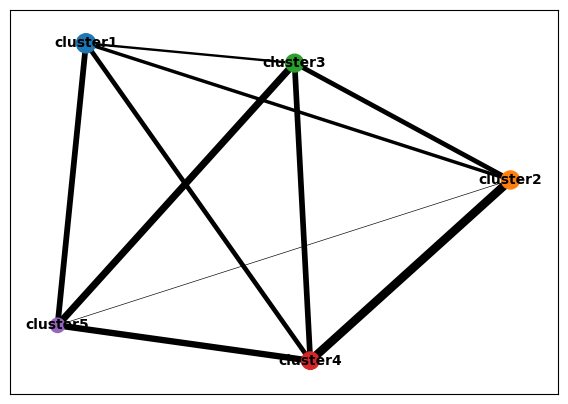

In [49]:
sc.pl.paga(
    adata,
    threshold=0
)

connectivity matrix

In [50]:
paga_conn = adata.uns["paga"]["connectivities"]

paga_df = pd.DataFrame(
    paga_conn.toarray(),
    index=adata.obs["cluster"].cat.categories,
    columns=adata.obs["cluster"].cat.categories
)

paga_df

,cluster1,cluster2,cluster3,cluster4,cluster5
cluster1,0.000000,0.330300,0.229837,0.447793,0.554435
cluster2,0.330300,0.000000,0.459030,0.821272,0.061424
cluster3,0.229837,0.459030,0.000000,0.545084,0.677714
cluster4,0.447793,0.821272,0.545084,0.000000,0.609870
cluster5,0.554435,0.061424,0.677714,0.609870,0.000000


correlate with existing time point information

In [51]:
cluster_time_counts = pd.crosstab(
    adata.obs["cluster"],
    adata.obs["timepoint"]
)

cluster_time_counts

timepoint,0,5,10,15
cluster,,,,
cluster1,13,18,13,17
cluster2,8,12,12,16
cluster3,9,10,14,12
cluster4,6,17,9,10
cluster5,0,2,8,9


In [52]:
cluster_time_fraction = pd.crosstab(
    adata.obs["cluster"],
    adata.obs["timepoint"],
    normalize="index"
)

cluster_time_fraction

timepoint,0,5,10,15
cluster,,,,
cluster1,0.213115,0.295082,0.213115,0.278689
cluster2,0.166667,0.250000,0.250000,0.333333
cluster3,0.200000,0.222222,0.311111,0.266667
cluster4,0.142857,0.404762,0.214286,0.238095
cluster5,0.000000,0.105263,0.421053,0.473684


## CXCL2 DPT root: 0-min medoid of the most 0-min-enriched Leiden cluster

Select the cluster with the highest within-cluster fraction of 0-min reads, then select the Manhattan medoid among its 0-min reads using all original site-level binary m6A features in `adata.X`. Mean distances exclude the candidate itself. Ties use the first cluster in group order or the first candidate in AnnData row order.

Timepoint only defines the root population; it is not included in distances or used to constrain pseudotime

In [78]:
# Recalculate within-cluster fractions from the existing CXCL2 observations.
root_cluster_fractions = (
    adata.obs["timepoint"].eq(0)
    .groupby(adata.obs["cluster"], observed=True)
    .mean()
)

if root_cluster_fractions.empty or root_cluster_fractions.max() <= 0:
    raise ValueError("No Leiden cluster contains a 0-min read for DPT root selection.")

root_cluster = root_cluster_fractions.idxmax()
root_cluster_fraction = float(root_cluster_fractions.loc[root_cluster])

print(f"Selected root cluster: {root_cluster}")
print(f"Fraction of 0-min reads in root cluster: {root_cluster_fraction:.6f}")

Selected root cluster: cluster1
Fraction of 0-min reads in root cluster: 0.213115


In [104]:
root_candidate_mask = (
    (adata.obs["cluster"] == root_cluster) &
    (adata.obs["timepoint"] == 0)
)
root_candidates = adata.obs.loc[root_candidate_mask]
n_root_candidates = len(root_candidates)

if n_root_candidates == 0:
    raise ValueError(f"Selected root cluster {root_cluster!r} contains no 0-min reads.")

print(f"Number of 0-min candidate reads: {n_root_candidates}")
root_candidates.head()

Number of 0-min candidate reads: 13


,cluster,sample_name,chr,start,end,strand,timepoint,dpt_pseudotime
RID,,,,,,,,
m84241_260505_203017_s4/102502771/ccs,cluster1,LPS_0,chr4,74092976,74105137,+,0,0.175959
m84241_260505_203017_s4/68358095/ccs,cluster1,LPS_0,chr4,74096842,74100283,+,0,0.000000
m84241_260613_000051_s2/106040976/ccs,cluster1,LPS_0,chr4,74097130,74106240,-,0,0.436265
m84241_260613_000051_s2/206767915/ccs,cluster1,LPS_0,chr4,74094612,74102823,+,0,0.107536
m84241_260613_000051_s2/34275500/ccs,cluster1,LPS_0,chr4,74092353,74101477,-,0,0.308993


Select the medoid and set its integer row index in the full AnnData object as the DPT root. For a single candidate, use that read and report a mean distance of 0 by convention (there are no other candidates).

In [105]:
if not adata.obs_names.is_unique:
    raise ValueError("AnnData RIDs must be unique to identify the DPT root row.")

# Keep positions in the full AnnData object; subset rows only, not m6A sites.
root_candidate_indices = np.flatnonzero(root_candidate_mask.to_numpy())

if n_root_candidates == 1:
    print("WARNING: Only one 0-min candidate read; using it as the DPT root. "
          "Mean distance is 0 by convention because there are no other candidates.")
    medoid_candidate_idx = 0
    medoid_mean_distance = 0.0
else:
    root_candidate_X = adata.X[root_candidate_indices, :]
    if sparse.issparse(root_candidate_X):
        root_candidate_X = root_candidate_X.toarray()

    # City-block distance is Manhattan distance; no metadata enters this calculation.
    root_candidate_distances = cdist(
        root_candidate_X,
        root_candidate_X,
        metric="cityblock"
    )
    # Self-distances are zero; divide by the number of OTHER candidates.
    root_candidate_mean_distances = (
        root_candidate_distances.sum(axis=1) / (n_root_candidates - 1)
    )
    medoid_candidate_idx = int(np.argmin(root_candidate_mean_distances))
    medoid_mean_distance = float(root_candidate_mean_distances[medoid_candidate_idx])

root_rid = root_candidates.index[medoid_candidate_idx]
if root_rid not in adata.obs_names:
    raise ValueError(f"Selected root RID {root_rid!r} is absent from adata.obs_names.")

root_idx = int(adata.obs_names.get_loc(root_rid))
adata.uns["iroot"] = root_idx

print(f"Selected root RID: {root_rid}")
print(f"AnnData row index of root: {root_idx}")
print(f"Mean Manhattan distance to other candidates: {medoid_mean_distance:.6f}")

Selected root RID: m84241_260505_203017_s4/68358095/ccs
AnnData row index of root: 43
Mean Manhattan distance to other candidates: 125.833333


## run diffusion map

In [81]:
sc.tl.diffmap(
    adata,
    n_comps=15
)

In [82]:
adata.obsm["X_diffmap"]

array([[ 0.0767683  , -0.10172156 , -0.04789328 , ...,  0.03867171 ,
        -0.025876138,  0.027392035],
       [ 0.06549081 ,  0.08064213 , -0.025294589, ..., -0.09253967 ,
         0.0595094  ,  0.090466276],
       [ 0.08009619 , -0.051784784, -0.06919384 , ..., -0.06936651 ,
        -0.040099874,  0.01134273 ],
       ...,
       [ 0.06646577 ,  0.09695124 ,  0.011227232, ..., -0.027654333,
         0.11093594 ,  0.1458611  ],
       [ 0.08220103 , -0.09369738 ,  0.11822118 , ..., -0.07499015 ,
        -0.012711435,  0.022993436],
       [ 0.050847944,  0.04428266 , -0.009484707, ..., -0.001385004,
        -0.03249244 , -0.027040571]], shape=(215, 15), dtype=float32)

1. run diffusion time analysis

In [83]:
sc.tl.dpt(
    adata,
    n_dcs=10,
    n_branchings=0
)

In [84]:
adata.obs[
    ["cluster", "timepoint", "dpt_pseudotime"]
].head(20)

,cluster,timepoint,dpt_pseudotime
RID,,,
m84241_260505_182714_s3/120329826/ccs,cluster1,5,0.233867
m84241_260505_182714_s3/141432141/ccs,cluster2,10,0.722293
m84241_260505_182714_s3/149425764/ccs,cluster1,5,0.278622
m84241_260505_182714_s3/154011751/ccs,cluster4,5,0.774929
m84241_260505_182714_s3/165874152/ccs,cluster3,10,0.711785
m84241_260505_182714_s3/181602117/ccs,cluster4,10,0.671881
m84241_260505_182714_s3/192546611/ccs,cluster1,10,0.358853
m84241_260505_182714_s3/21103640/ccs,cluster2,5,0.781254
m84241_260505_182714_s3/228066721/ccs,cluster4,5,0.536983


#### Pseudotime against time point information

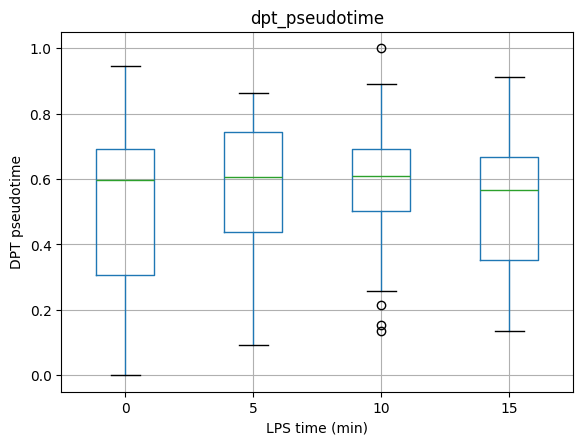

In [103]:
adata.obs.boxplot(
    column="dpt_pseudotime",
    by="timepoint"
)

plt.xlabel("LPS time (min)")
plt.ylabel("DPT pseudotime")
plt.suptitle("")
plt.show()

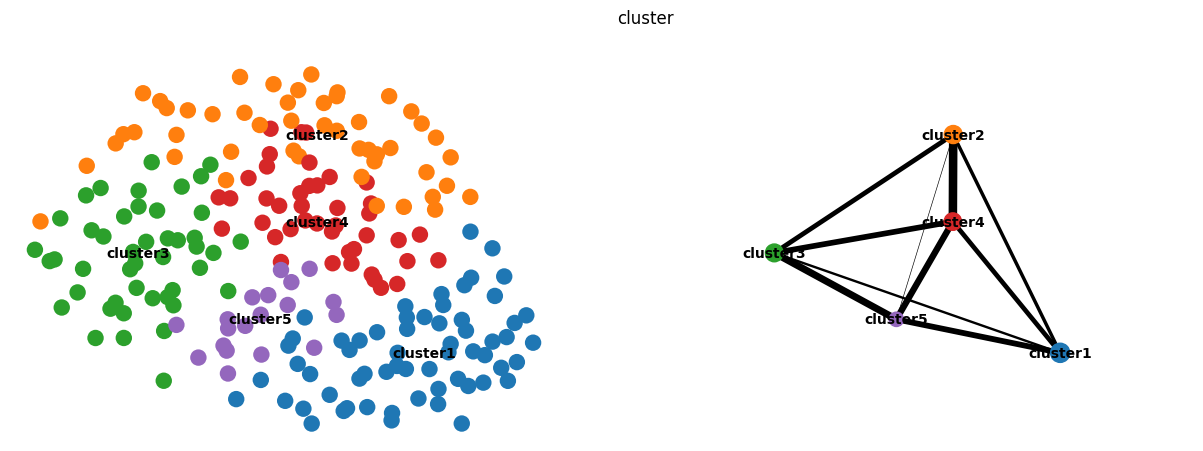

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

In [69]:
sc.pl.paga_compare(
    adata,
    basis="umap",
    color="cluster",
    threshold=0.05
)

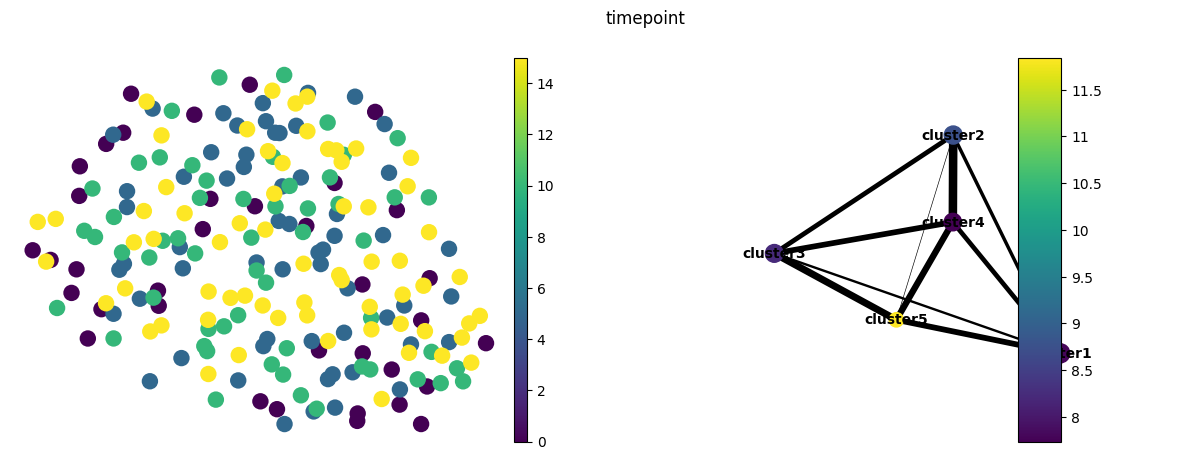

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

In [70]:
sc.pl.paga_compare(
    adata,
    basis="umap",
    color="timepoint",
    threshold=0.05
)

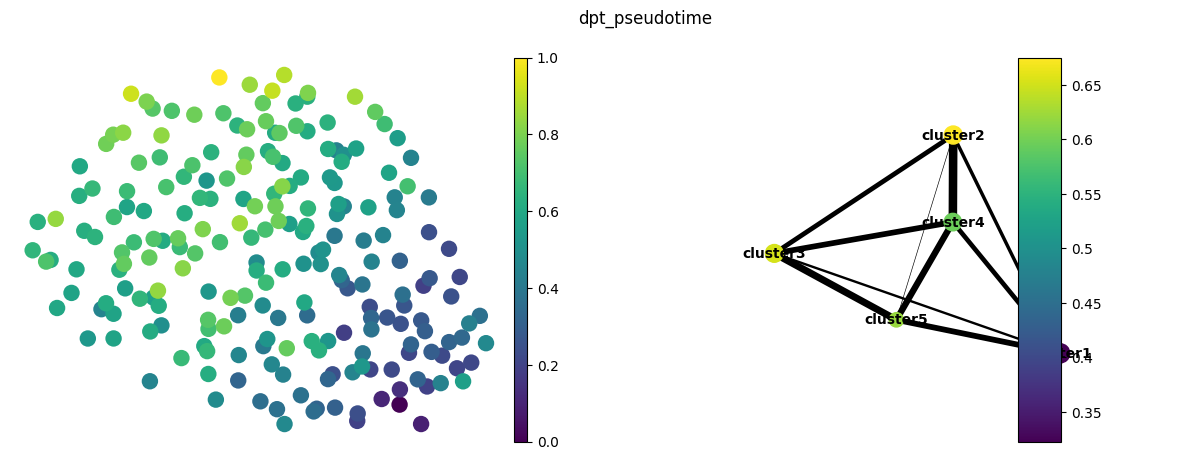

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

In [71]:
sc.pl.paga_compare(
    adata,
    basis="umap",
    color="dpt_pseudotime",
    threshold=0.05
)

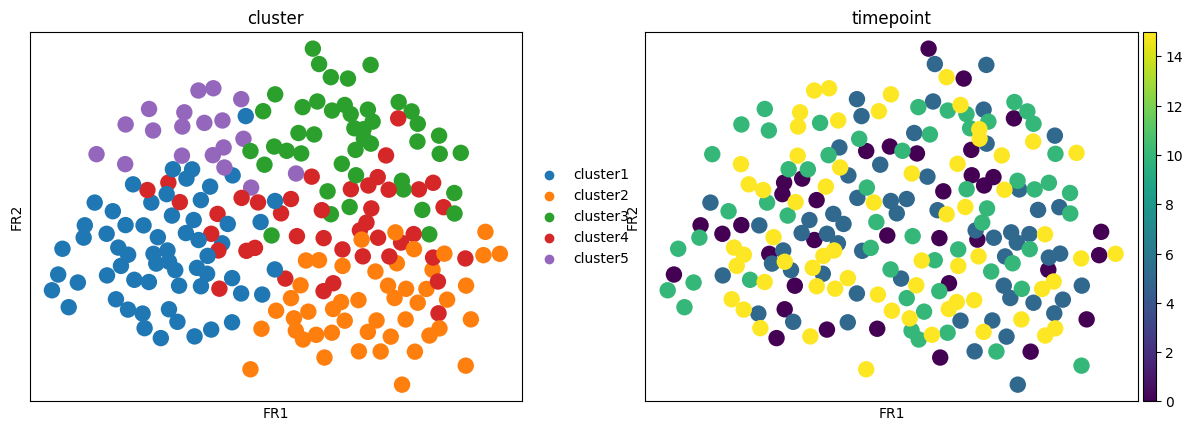

In [72]:
sc.tl.draw_graph(
    adata,
    init_pos="paga"
)

sc.pl.draw_graph(
    adata,
    color=["cluster", "timepoint"]
)

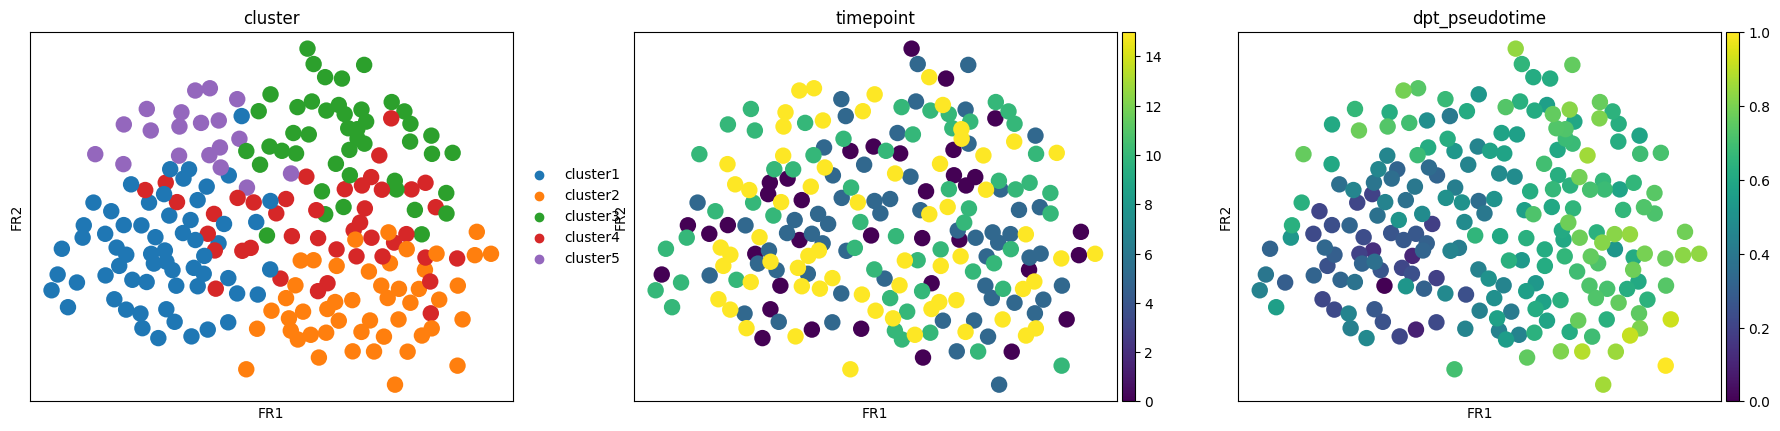

In [73]:
sc.pl.draw_graph(
    adata,
    color=["cluster", "timepoint", "dpt_pseudotime"]
)

<Axes: title={'center': 'dpt_pseudotime'}, xlabel='cluster'>

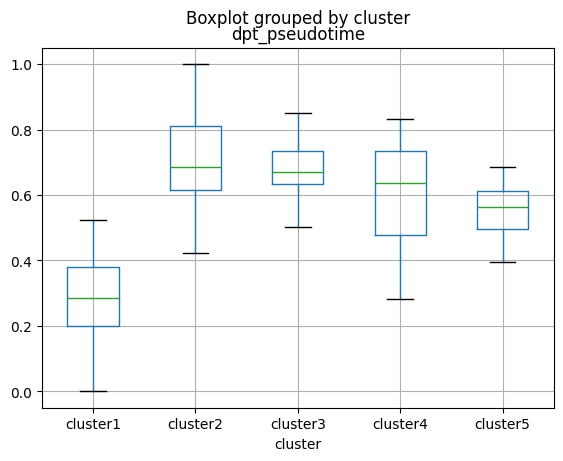

In [102]:
adata.obs.boxplot(
    column="dpt_pseudotime",
    by="cluster"
)

## CXCL2: cluster-level DPT summaries

Use the existing CXCL2 `adata`, Leiden clusters, and 0-min Manhattan medoid root. This section does not rerun clustering, graph construction, PAGA, diffusion maps, or DPT. The original per-read `dpt_pseudotime` is retained. The existing PAGA network above describes connections between clusters without specifying a biological path.

Median DPT summarizes each cluster while the boxplots retain its full within-cluster distribution. Experimental time is used to summarize composition and evaluate association. All correlations below give each cluster one observation. Cluster ordering in the displays does not modify the scores or establish a biological sequence.

In [128]:
from scipy.stats import spearmanr
from IPython.display import display

if gene != "CXCL2":
    raise ValueError("This cluster-level DPT section is for the existing CXCL2 adata only.")

required_obs = {"cluster", "timepoint", "dpt_pseudotime"}
if not required_obs.issubset(adata.obs.columns):
    raise ValueError(f"Missing observation fields: {required_obs - set(adata.obs.columns)}")
if not isinstance(adata.obs["cluster"].dtype, pd.CategoricalDtype):
    raise ValueError("Categorical Leiden cluster assignments are required for these summaries.")

cxcl2_obs = adata.obs[["cluster", "timepoint", "dpt_pseudotime"]].copy()
cxcl2_timepoints = [0, 5, 10, 15]
cxcl2_obs["timepoint"] = pd.to_numeric(cxcl2_obs["timepoint"], errors="raise")
if cxcl2_obs["cluster"].isna().any() or not cxcl2_obs["timepoint"].isin(cxcl2_timepoints).all():
    raise ValueError("Each read must have a cluster and an experimental time of 0, 5, 10, or 15 min.")

cluster_summary = cxcl2_obs.groupby("cluster", observed=True).agg(
    cluster_dpt_pseudotime=("dpt_pseudotime", "median"),
    mean_dpt_pseudotime=("dpt_pseudotime", "mean"),
    n_reads=("dpt_pseudotime", "size"),
    mean_real_time=("timepoint", "mean"),
    median_real_time=("timepoint", "median")
)
cluster_timepoint_fractions = (
    pd.crosstab(cxcl2_obs["cluster"], cxcl2_obs["timepoint"])
    .reindex(index=cluster_summary.index, columns=cxcl2_timepoints, fill_value=0)
    .div(cluster_summary["n_reads"], axis=0)
)
cluster_timepoint_fractions.columns = [f"fraction_{t}_min" for t in cxcl2_timepoints]
timepoint_fraction_columns = cluster_timepoint_fractions.columns.tolist()
cluster_summary = cluster_summary.join(cluster_timepoint_fractions).sort_values(
    "cluster_dpt_pseudotime", kind="stable"
)

print("CXCL2 cluster summary, ordered by median DPT:")
print(cluster_summary.to_string(float_format=lambda value: f"{value:.4f}"))
display(cluster_summary)

CXCL2 cluster summary, ordered by median DPT:
          cluster_dpt_pseudotime  mean_dpt_pseudotime  n_reads  mean_real_time  median_real_time  fraction_0_min  fraction_5_min  fraction_10_min  fraction_15_min
cluster                                                                                                                                                           
cluster1                  0.2842               0.2916       61          7.7869            5.0000          0.2131          0.2951           0.2131           0.2787
cluster5                  0.5636               0.5568       19         11.8421           10.0000          0.0000          0.1053           0.4211           0.4737
cluster4                  0.6372               0.6049       42          7.7381            5.0000          0.1429          0.4048           0.2143           0.2381
cluster3                  0.6698               0.6775       45          8.2222           10.0000          0.2000          0.2222           

,cluster_dpt_pseudotime,mean_dpt_pseudotime,n_reads,mean_real_time,median_real_time,fraction_0_min,fraction_5_min,fraction_10_min,fraction_15_min
cluster,,,,,,,,,
cluster1,0.284209,0.291574,61,7.786885,5.0,0.213115,0.295082,0.213115,0.278689
cluster5,0.563650,0.556841,19,11.842105,10.0,0.000000,0.105263,0.421053,0.473684
cluster4,0.637210,0.604926,42,7.738095,5.0,0.142857,0.404762,0.214286,0.238095
cluster3,0.669809,0.677453,45,8.222222,10.0,0.200000,0.222222,0.311111,0.266667
cluster2,0.685305,0.701712,48,8.750000,10.0,0.166667,0.250000,0.250000,0.333333


### Cluster median DPT versus experimental time

With only a few CXCL2 clusters, the effect direction and cluster ordering are more informative than the p-value alone. Point area is proportional to the number of reads, but the Spearman correlation weights clusters equally.

Cluster median DPT vs mean experimental time (5 clusters)
Spearman rho: 0.2000
p-value: 0.74706


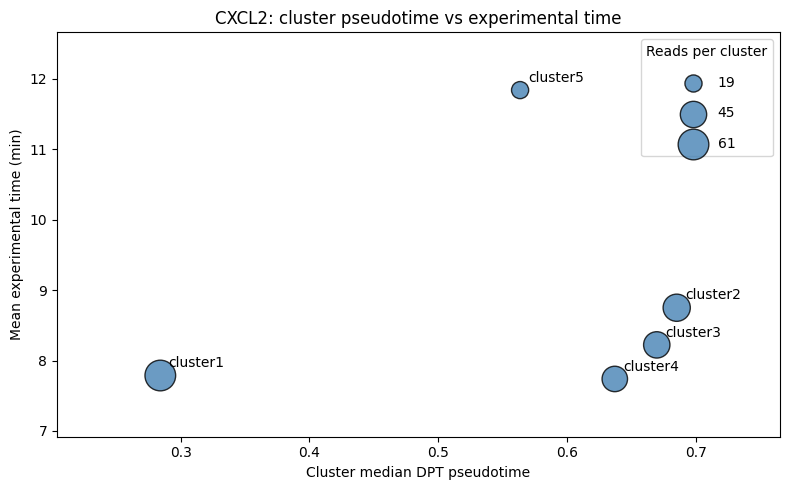

In [129]:
def report_cluster_time_spearman(table, score_column, label):
    paired = table[[score_column, "mean_real_time"]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(paired) < 2 or (paired.nunique() < 2).any():
        rho, p_value = np.nan, np.nan
        print(f"WARNING: {label} correlation requires at least two clusters and nonconstant values.")
    else:
        rho, p_value = spearmanr(paired[score_column], paired["mean_real_time"])
    # With few clusters, effect direction and cluster ordering matter more than p alone.
    print(f"{label} vs mean experimental time ({len(paired)} clusters)")
    print(f"Spearman rho: {rho:.4f}")
    print(f"p-value: {p_value:.6g}")
    return rho, p_value


def plot_cluster_time_score(table, score_column, xlabel, title):
    plotted = table.replace([np.inf, -np.inf], np.nan).dropna(subset=[score_column, "mean_real_time"])
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(
        plotted[score_column], plotted["mean_real_time"],
        s=plotted["n_reads"] * 8, color="steelblue", edgecolor="black", alpha=0.8
    )
    for cluster, values in plotted.iterrows():
        ax.annotate(str(cluster), (values[score_column], values["mean_real_time"]),
                    xytext=(6, 6), textcoords="offset points")
    if not plotted.empty:
        legend_counts = sorted({int(plotted["n_reads"].min()),
                                int(plotted["n_reads"].median()),
                                int(plotted["n_reads"].max())})
        for count in legend_counts:
            ax.scatter([], [], s=count * 8, color="steelblue", edgecolor="black",
                       alpha=0.8, label=str(count))
        ax.legend(title="Reads per cluster", loc="best", labelspacing=1.2)
    ax.set(xlabel=xlabel, ylabel="Mean experimental time (min)", title=title)
    ax.margins(x=0.2, y=0.2)
    fig.tight_layout()
    plt.show()


cluster_dpt_spearman_rho, cluster_dpt_spearman_pvalue = report_cluster_time_spearman(
    cluster_summary, "cluster_dpt_pseudotime", "Cluster median DPT"
)
plot_cluster_time_score(
    cluster_summary, "cluster_dpt_pseudotime", "Cluster median DPT pseudotime",
    "CXCL2: cluster pseudotime vs experimental time"
)

### Read-level annotations and within-cluster DPT percentile

`dpt_pseudotime` is the original individual-read DPT; `cluster_dpt_pseudotime` is its cluster's median DPT.

For `within_cluster_dpt_percentile`, calculate average ranks within each cluster and rescale the minimum and maximum ranks to 0 and 1. Ties receive the same percentile. Singleton or constant-DPT clusters receive 0 by convention; missing DPT values remain NaN. Keep this percentile separate from the original DPT, which is used for the heatmap's within-cluster ordering and point annotation.

In [130]:
# Map by cluster label; never overwrite the original individual-read DPT.
adata.obs["cluster_dpt_pseudotime"] = (
    adata.obs["cluster"].map(cluster_summary["cluster_dpt_pseudotime"]).astype(float)
)
within_cluster_dpt_ranks = adata.obs.groupby("cluster", observed=True)["dpt_pseudotime"].rank(
    method="average", na_option="keep"
)
within_cluster_rank_groups = within_cluster_dpt_ranks.groupby(adata.obs["cluster"], observed=True)
within_cluster_min_rank = within_cluster_rank_groups.transform("min")
within_cluster_rank_span = within_cluster_rank_groups.transform("max") - within_cluster_min_rank
adata.obs["within_cluster_dpt_percentile"] = (
    (within_cluster_dpt_ranks - within_cluster_min_rank)
    / within_cluster_rank_span.replace(0, np.nan)
).mask(within_cluster_rank_span.eq(0) & within_cluster_dpt_ranks.notna(), 0.0)

display(adata.obs[
    ["cluster", "timepoint", "dpt_pseudotime", "cluster_dpt_pseudotime",
     "within_cluster_dpt_percentile"]
].head())

,cluster,timepoint,dpt_pseudotime,cluster_dpt_pseudotime,within_cluster_dpt_percentile
RID,,,,,
m84241_260505_182714_s3/120329826/ccs,cluster1,5,0.233867,0.284209,0.333333
m84241_260505_182714_s3/141432141/ccs,cluster2,10,0.722293,0.685305,0.574468
m84241_260505_182714_s3/149425764/ccs,cluster1,5,0.278622,0.284209,0.466667
m84241_260505_182714_s3/154011751/ccs,cluster4,5,0.774929,0.637210,0.853659
m84241_260505_182714_s3/165874152/ccs,cluster3,10,0.711785,0.669809,0.659091


### Diagnostic comparisons of read-level and cluster-level DPT

Cluster median DPT is repeated for each read in the corresponding boxplot, so its distribution by experimental time reflects cluster composition. These repeated values do not add independent trajectory measurements. The read-level boxplots retain the original within-cluster variation; clusters are displayed in median DPT order.

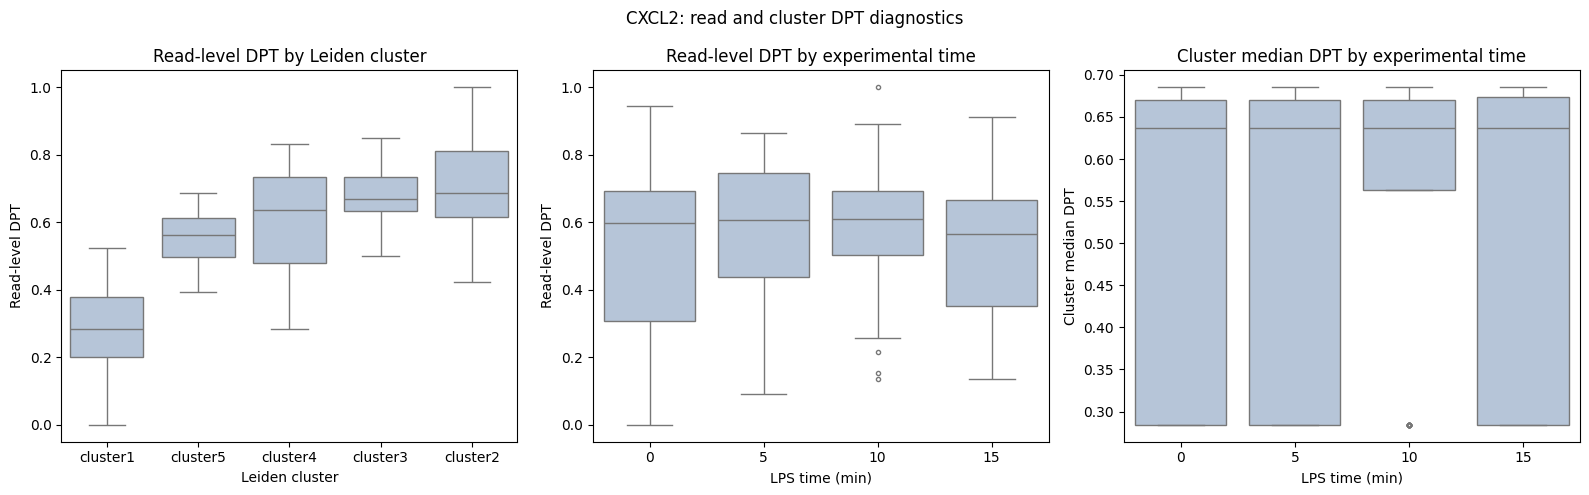

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(
    data=adata.obs, x="cluster", y="dpt_pseudotime",
    order=cluster_summary.index.tolist(), color="lightsteelblue", fliersize=3, ax=axes[0]
)
axes[0].set(title="Read-level DPT by Leiden cluster", xlabel="Leiden cluster", ylabel="Read-level DPT")
for ax, column, title, ylabel in [
    (axes[1], "dpt_pseudotime", "Read-level DPT by experimental time", "Read-level DPT"),
    (axes[2], "cluster_dpt_pseudotime", "Cluster median DPT by experimental time", "Cluster median DPT")
]:
    sns.boxplot(data=adata.obs, x="timepoint", y=column, order=cxcl2_timepoints,
                color="lightsteelblue", fliersize=3, ax=ax)
    ax.set(title=title, xlabel="LPS time (min)", ylabel=ylabel)
fig.suptitle("CXCL2: read and cluster DPT diagnostics")
fig.tight_layout()
plt.show()

### Experimental-time composition by Leiden cluster

Display clusters in median DPT order. This is a display choice, not an inferred biological path. Each bar contains the within-cluster fractions at 0, 5, 10, and 15 min.

Cluster composition displayed in median DPT order; this does not specify a biological path.


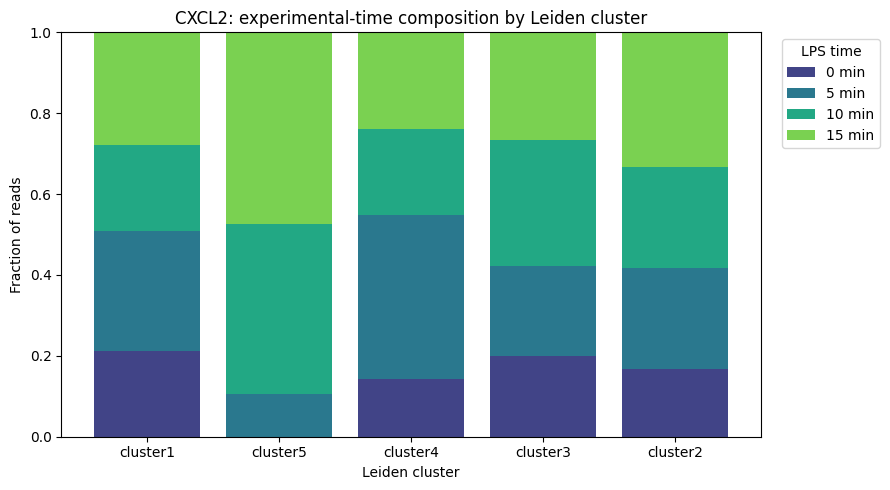

In [132]:
cluster_display_order = cluster_summary.sort_values(
    "cluster_dpt_pseudotime", kind="stable"
).index
print("Cluster composition displayed in median DPT order; this does not specify a biological path.")

cluster_composition = cluster_summary.loc[cluster_display_order, timepoint_fraction_columns].copy()
cluster_composition.columns = [f"{t} min" for t in cxcl2_timepoints]
ax = cluster_composition.plot.bar(
    stacked=True, figsize=(9, 5), width=0.8, color=sns.color_palette("viridis", 4), rot=0
)
ax.set(xlabel="Leiden cluster", ylabel="Fraction of reads", ylim=(0, 1),
       title="CXCL2: experimental-time composition by Leiden cluster")
ax.legend(title="LPS time", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.figure.tight_layout()
plt.show()

### CXCL2: m6A heatmap with cluster and DPT annotations

Group reads by their existing Leiden cluster, display cluster blocks in median DPT order, and sort reads within each block by their original individual-read DPT. Cluster grouping and block order are display choices, not an inferred biological path; the AnnData row order and all DPT values remain unchanged.

Align categorical cluster and experimental-time strips and a DPT point annotation with every heatmap row. DPT uses the same original 0–1 scale across clusters. Horizontal lines mark cluster boundaries. All panels use the same row permutation, and the heatmap retains all original site-level m6A features. Experimental time is an annotation only and does not enter the sorting.

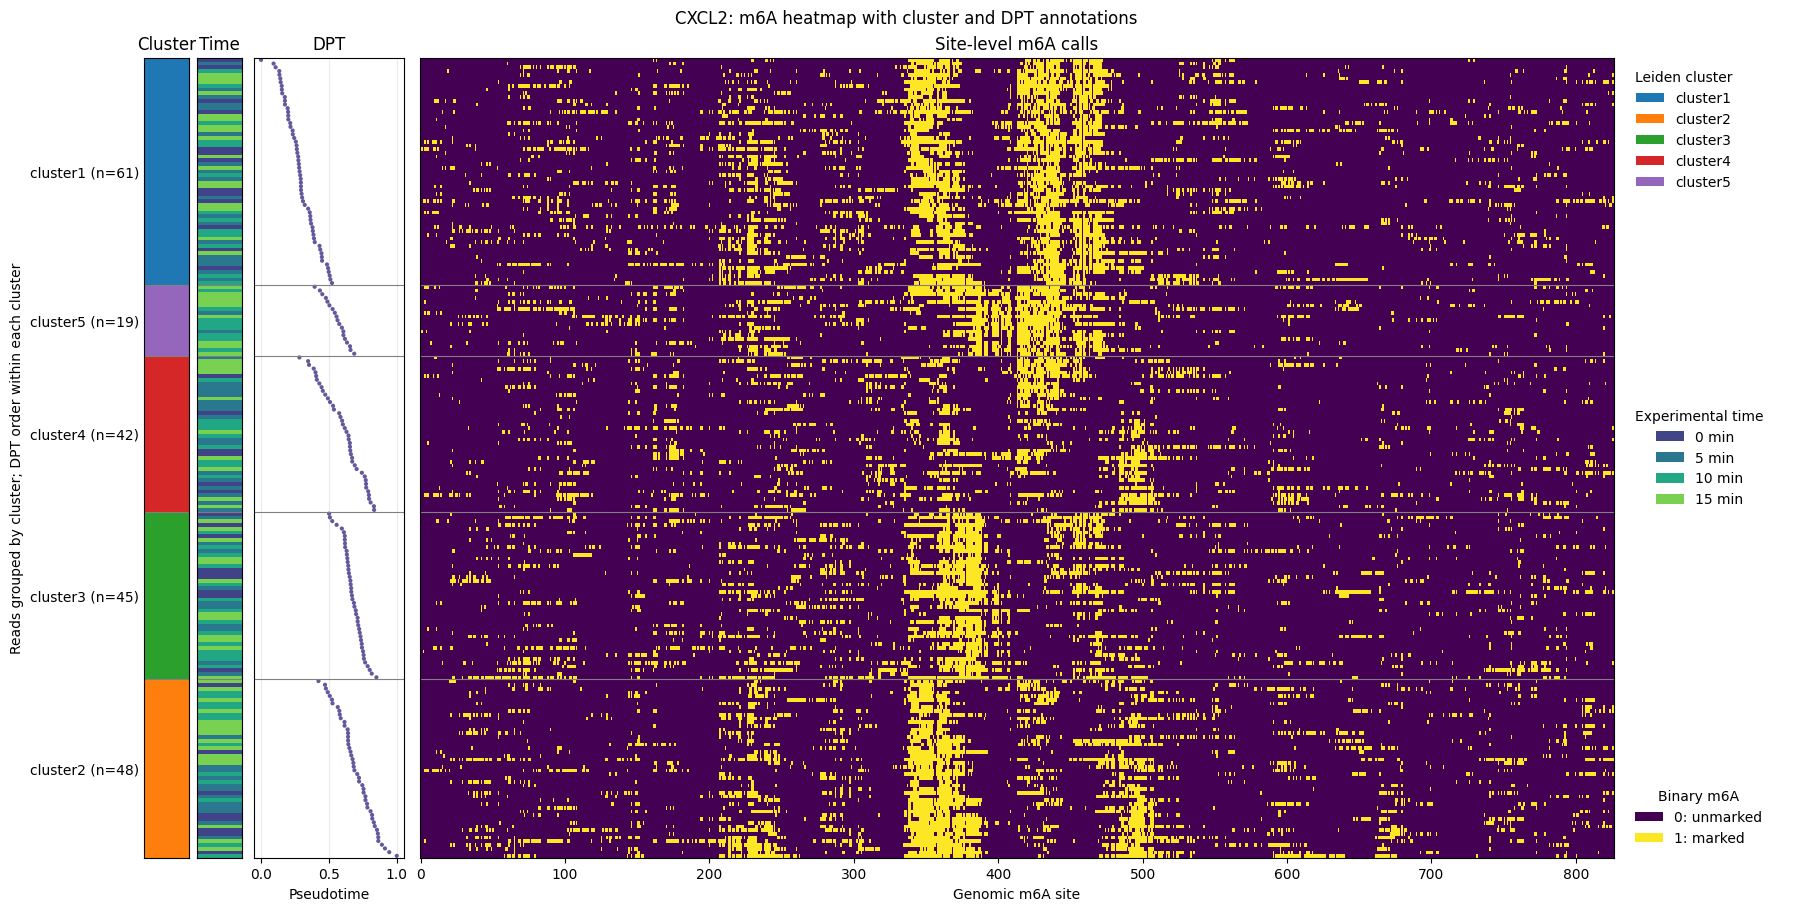

In [133]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

if gene != "CXCL2":
    raise ValueError("This annotated heatmap is for the existing CXCL2 adata only.")
heatmap_pseudotime = adata.obs["dpt_pseudotime"].to_numpy()
heatmap_clusters = adata.obs["cluster"].astype("category")
heatmap_timepoints = [0, 5, 10, 15]
heatmap_times = pd.to_numeric(adata.obs["timepoint"], errors="raise")
if adata.n_obs == 0 or not np.isfinite(heatmap_pseudotime).all():
    raise ValueError("The annotated heatmap requires reads with finite DPT pseudotime.")
if heatmap_clusters.isna().any():
    raise ValueError("Each heatmap read must have a Leiden cluster annotation.")
if not heatmap_times.isin(heatmap_timepoints).all():
    raise ValueError("Each heatmap read must have an experimental time of 0, 5, 10, or 15 min.")

# Display order only: cluster median DPT, then original read DPT within each cluster.
heatmap_cluster_order = (
    adata.obs.groupby("cluster", observed=True)["dpt_pseudotime"]
    .median().sort_values(kind="stable").index
)
heatmap_order = np.concatenate([
    np.flatnonzero(heatmap_clusters.eq(cluster).to_numpy())[
        np.argsort(
            heatmap_pseudotime[heatmap_clusters.eq(cluster).to_numpy()], kind="stable"
        )
    ]
    for cluster in heatmap_cluster_order
])
# Apply one permutation to the matrix and every annotation; do not reorder adata.
heatmap_X_ordered = adata.X[heatmap_order, :]
heatmap_X_ordered = (
    heatmap_X_ordered.toarray() if sparse.issparse(heatmap_X_ordered)
    else np.asarray(heatmap_X_ordered)
)
heatmap_dpt_ordered = heatmap_pseudotime[heatmap_order]
heatmap_cluster_codes = heatmap_clusters.cat.codes.to_numpy()[heatmap_order]
heatmap_cluster_names = heatmap_clusters.cat.categories
heatmap_time_codes = pd.Categorical(
    heatmap_times, categories=heatmap_timepoints, ordered=True
).codes[heatmap_order]
heatmap_read_rows = np.arange(adata.n_obs)
heatmap_block_counts = (
    heatmap_clusters.value_counts().reindex(heatmap_cluster_order).to_numpy()
)
heatmap_block_ends = np.cumsum(heatmap_block_counts)
heatmap_block_starts = np.r_[0, heatmap_block_ends[:-1]]
heatmap_block_centers = (heatmap_block_starts + heatmap_block_ends - 1) / 2
heatmap_boundaries = heatmap_block_ends[:-1] - 0.5

# Reuse the existing Scanpy cluster colors in categorical order.
heatmap_cluster_colors = adata.uns.get("cluster_colors")
if heatmap_cluster_colors is None or len(heatmap_cluster_colors) != len(heatmap_cluster_names):
    heatmap_cluster_colors = sns.color_palette("husl", len(heatmap_cluster_names))
heatmap_time_colors = sns.color_palette("viridis", len(heatmap_timepoints))

annotated_heatmap_fig = plt.figure(figsize=(18, 9), layout="constrained")
heatmap_grid = annotated_heatmap_fig.add_gridspec(
    1, 5, width_ratios=[0.45, 0.45, 1.5, 12, 1.8]
)
heatmap_cluster_ax = annotated_heatmap_fig.add_subplot(heatmap_grid[0, 0])
heatmap_time_ax = annotated_heatmap_fig.add_subplot(heatmap_grid[0, 1], sharey=heatmap_cluster_ax)
heatmap_dpt_ax = annotated_heatmap_fig.add_subplot(heatmap_grid[0, 2], sharey=heatmap_cluster_ax)
heatmap_matrix_ax = annotated_heatmap_fig.add_subplot(heatmap_grid[0, 3], sharey=heatmap_cluster_ax)
heatmap_legend_ax = annotated_heatmap_fig.add_subplot(heatmap_grid[0, 4])

heatmap_cluster_ax.imshow(
    heatmap_cluster_codes[:, None], aspect="auto", interpolation="nearest", origin="upper",
    cmap=ListedColormap(heatmap_cluster_colors), vmin=-0.5, vmax=len(heatmap_cluster_names) - 0.5
)
heatmap_cluster_ax.set(title="Cluster", xticks=[], ylabel="Reads grouped by cluster; DPT order within each cluster")
heatmap_cluster_ax.set_yticks(heatmap_block_centers)
heatmap_cluster_ax.set_yticklabels([
    f"{cluster} (n={count})" for cluster, count in zip(heatmap_cluster_order, heatmap_block_counts)
])
heatmap_cluster_ax.tick_params(axis="y", length=0)

heatmap_time_ax.imshow(
    heatmap_time_codes[:, None], aspect="auto", interpolation="nearest", origin="upper",
    cmap=ListedColormap(heatmap_time_colors), vmin=-0.5, vmax=len(heatmap_timepoints) - 0.5
)
heatmap_time_ax.set(title="Time", xticks=[])
heatmap_time_ax.tick_params(axis="y", left=False, labelleft=False)

heatmap_dpt_ax.scatter(
    heatmap_dpt_ordered, heatmap_read_rows, s=9, color="darkslateblue", edgecolors="none", alpha=0.85
)
heatmap_dpt_ax.set(title="DPT", xlabel="Pseudotime", xlim=(-0.05, 1.05), xticks=[0, 0.5, 1])
heatmap_dpt_ax.grid(axis="x", alpha=0.25)
heatmap_dpt_ax.set_axisbelow(True)
heatmap_dpt_ax.tick_params(axis="y", left=False, labelleft=False)

heatmap_image = heatmap_matrix_ax.imshow(
    heatmap_X_ordered, aspect="auto", interpolation="nearest", origin="upper",
    cmap="viridis", vmin=0, vmax=1
)
heatmap_matrix_ax.set(xlabel="Genomic m6A site", title="Site-level m6A calls")
heatmap_matrix_ax.tick_params(axis="y", left=False, labelleft=False)
for heatmap_ax in [heatmap_cluster_ax, heatmap_time_ax, heatmap_dpt_ax, heatmap_matrix_ax]:
    for heatmap_boundary in heatmap_boundaries:
        heatmap_ax.axhline(heatmap_boundary, color="gray", linewidth=0.8)
heatmap_cluster_ax.set_ylim(adata.n_obs - 0.5, -0.5)

heatmap_legend_ax.axis("off")
heatmap_cluster_legend = heatmap_legend_ax.legend(
    handles=[Patch(facecolor=color, label=str(cluster))
             for cluster, color in zip(heatmap_cluster_names, heatmap_cluster_colors)],
    title="Leiden cluster", loc="upper left", frameon=False
)
heatmap_legend_ax.add_artist(heatmap_cluster_legend)
heatmap_time_legend = heatmap_legend_ax.legend(
    handles=[Patch(facecolor=color, label=f"{timepoint} min")
             for timepoint, color in zip(heatmap_timepoints, heatmap_time_colors)],
    title="Experimental time", loc="center left", frameon=False
)
heatmap_legend_ax.add_artist(heatmap_time_legend)
heatmap_legend_ax.legend(
    handles=[Patch(facecolor=heatmap_image.cmap(0.0), label="0: unmarked"),
             Patch(facecolor=heatmap_image.cmap(1.0), label="1: marked")],
    title="Binary m6A", loc="lower left", frameon=False
)
annotated_heatmap_fig.suptitle("CXCL2: m6A heatmap with cluster and DPT annotations")
plt.show()